<a href="https://colab.research.google.com/github/GAUTAMDEORA/DS_NLP/blob/main/NLP_2_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# use to fetch web page
import requests
# extract content from web page
from bs4 import BeautifulSoup

def get_article_text(url):
    '''Extracts and returns only the main text from a given URL.'''
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36'
        }

        response = requests.get(url, headers=headers)
        response.raise_for_status()
        soup = BeautifulSoup(response.text, 'lxml')


        content_divs = soup.find_all('div', class_="elementor-widget-container")

        # Extract text from all <p> tags inside these divs and combine them
        article_text = "\n\n".join([p.get_text() for div in content_divs for p in div.find_all('p')])

        return article_text.strip() if article_text else "No text found"

    except Exception as e:
        print(f"Error: {e}")
        return None

def extract_articles(article_names_and_urls):
    articles = {}

    for name, url in article_names_and_urls.items():
        print(f"Extracting article: {name}")
        article_text = get_article_text(url)
        if article_text:
            articles[name] = article_text
        else:
            articles[name] = "Failed to extract article"

    return articles

# Define article names and corresponding URLs in the dictionary
article_names_and_urls = {
    "Trump": "https://scrapsfromtheloft.com/opinions/trump-and-the-decline-of-the-american-people/",
    "Jeffrey Sachs": "https://scrapsfromtheloft.com/opinions/jeffrey-sachs-can-there-be-peace-with-netanyahu-transcript/",
    "Kaja Kallas": "https://scrapsfromtheloft.com/opinions/the-pure-genius-of-kaja-kallas/",
    "Alberto Piroddi":"https://scrapsfromtheloft.com/opinions/why-do-the-poor-in-america-elect-the-rich/",
    "Massimo Cacciari":"https://scrapsfromtheloft.com/opinions/the-musks-the-machine-and-the-left-out-of-play/"

}

# Extract articles
extracted_articles = extract_articles(article_names_and_urls)

# Print the extracted articles
for name, article_text in extracted_articles.items():
    print(f"\nArticle: {name}\n")
    print(article_text[:500])  # Print only the first 500 characters for preview
    print("\n" + "="*50 + "\n")

Extracting article: Trump
Extracting article: Jeffrey Sachs
Extracting article: Kaja Kallas
Extracting article: Alberto Piroddi
Extracting article: Massimo Cacciari

Article: Trump

by Pino Arlacchi

Trump’s inaugural address and his first executive orders typify the debut of a populist leader promising to rescue the people from their perceived plight and lead them toward a path of rebirth.

How many times have we seen this dismal spectacle? From Mussolini to Hitler, from Berlusconi to today’s xenophobic European leaders, countless figures have promised national greatness and prosperity through their personal charisma, only to collapse ignominiously—and often tragically—und



Article: Jeffrey Sachs

Judge Andrew Napolitano and Professor Jeffrey Sachs discussed key geopolitical issues on Judging Freedom, including Donald Trump’s executive order to declassify files related to the assassinations of JFK, RFK, and MLK, raising questions about transparency and potential revelations. They ex

In [ ]:
import pickle5
def save_articles_to_files_and_pickle(articles):
    '''Saves each article in a separate text file and a pickle file.'''

    # Save articles as .txt files
    for name, article_text in articles.items():
        # Sanitize the article title for use as a filename
        filename = f"{name.replace(' ', '_').replace('/', '_').replace(':', '')}.txt"

        # Save the article text to a text file
        with open(filename, "w", encoding="utf-8") as file:
            file.write(article_text)

        print(f"Article '{name}' saved as '{filename}'")

    # Save the articles as a pickle file
    with open("articles.pkl", "wb") as pickle_file:
        pickle.dump(articles, pickle_file)

    print("All articles saved as 'articles.pkl'")


# Save articles to text files and pickle file
save_articles_to_files_and_pickle(extracted_articles)

Article 'Trump' saved as 'Trump.txt'
Article 'Jeffrey Sachs' saved as 'Jeffrey_Sachs.txt'
Article 'Kaja Kallas' saved as 'Kaja_Kallas.txt'
Article 'Alberto Piroddi' saved as 'Alberto_Piroddi.txt'
Article 'Massimo Cacciari' saved as 'Massimo_Cacciari.txt'
All articles saved as 'articles.pkl'


In [ ]:
import pickle

# Load the saved articles from the pickle file
with open("articles.pkl", "rb") as file:
    articles = pickle.load(file)

# Print a preview of each article
for name, article_text in articles.items():
    print(f"\nArticle: {name}\n")
    print(article_text[:500])
    print("\n" + "="*50 + "\n")



Article: Trump

by Pino Arlacchi

Trump’s inaugural address and his first executive orders typify the debut of a populist leader promising to rescue the people from their perceived plight and lead them toward a path of rebirth.

How many times have we seen this dismal spectacle? From Mussolini to Hitler, from Berlusconi to today’s xenophobic European leaders, countless figures have promised national greatness and prosperity through their personal charisma, only to collapse ignominiously—and often tragically—und



Article: Jeffrey Sachs

Judge Andrew Napolitano and Professor Jeffrey Sachs discussed key geopolitical issues on Judging Freedom, including Donald Trump’s executive order to declassify files related to the assassinations of JFK, RFK, and MLK, raising questions about transparency and potential revelations. They examined the Ukraine war, predicting its imminent end due to anticipated U.S. withdrawal of support under a Republican Congress, and criticized the Biden administratio

In [ ]:
# for removing numbers
import re
# for removing punctuation
import string
# for stopwords
import nltk
from nltk.corpus import stopwords
# Download stopwords if not already downloaded
nltk.download('stopwords')

# Load the articles from the pickle file
with open("articles.pkl", "rb") as file:
    articles = pickle.load(file)

# Initialize stop words
stop_words = set(stopwords.words('english'))

# Function to clean a single article text
def clean_article_text(article_text):
    # Step 1: Convert text to lowercase
    article_text = article_text.lower()

    # Step 2: Remove punctuation
    article_text = article_text.translate(str.maketrans("", "", string.punctuation))

    # Step 3: Remove numerical values
    article_text = re.sub(r'\d+', '', article_text)

    # Step 4: newlines and extra spaces
    article_text = article_text.replace("\n", " ").strip()

    # Step 5: Remove stop words
    filtered_words = [word for word in article_text.split() if word not in stop_words]

    # Join back into a cleaned text
    cleaned_text = " ".join(filtered_words)

    return cleaned_text

# Process each article in the pickle file
cleaned_articles = {name: clean_article_text(text) for name, text in articles.items()}

# Print cleaned previews of each article
for name, cleaned_text in cleaned_articles.items():
    print(f"\nArticle: {name}\n")
    print(cleaned_text[:500])  # Print only the first 500 characters for preview
    print("\n" + "="*50 + "\n")



Article: Trump

pino arlacchi trump’s inaugural address first executive orders typify debut populist leader promising rescue people perceived plight lead toward path rebirth many times seen dismal spectacle mussolini hitler berlusconi today’s xenophobic european leaders countless figures promised national greatness prosperity personal charisma collapse ignominiously—and often tragically—under weight economic crises wars betrayal interests initially supported true trump came power democratic elections however ri



Article: Jeffrey Sachs

judge andrew napolitano professor jeffrey sachs discussed key geopolitical issues judging freedom including donald trump’s executive order declassify files related assassinations jfk rfk mlk raising questions transparency potential revelations examined ukraine war predicting imminent end due anticipated us withdrawal support republican congress criticized biden administration’s handling conflict discussion also addressed instability benjamin netanyahu

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import pandas as pd

# Create the Corpus (DataFrame)
cleaned_articles = {name: clean_article_text(text) for name, text in articles.items()}
corpus_df = pd.DataFrame(list(cleaned_articles.items()), columns=['Article', 'Text'])

# Save the Corpus to a CSV
corpus_df.to_csv("corpus.csv", index=False)

# Print the Corpus preview
print("Corpus DataFrame:")
print(corpus_df.head())  # Show first few articles


Corpus DataFrame:
            Article                                               Text
0             Trump  pino arlacchi trump’s inaugural address first ...
1     Jeffrey Sachs  judge andrew napolitano professor jeffrey sach...
2       Kaja Kallas  marco travaglio among drunken pygmies socalled...
3   Alberto Piroddi  alberto piroddi phenomenon poor americans elec...
4  Massimo Cacciari  massimo cacciari “put musks charge” – seems en...


In [ ]:
# ngram_range=(1,2)

# This includes both unigrams (single words) and bigrams (two-word phrases) in the feature set.

# Example:

# Unigrams: "economy", "growth", "policy"

# Bigrams: "economic growth", "policy change", "interest rates"

# min_df=2 (Minimum Document Frequency)

# Ignores words that appear in fewer than 2 documents.

# This removes rare words that might not be useful for analysis.

# max_df=0.8 (Maximum Document Frequency)

# Ignores words that appear in more than 80% of the documents.

# This removes very common words that might not add meaningful information (e.g., "said", "people", "year").

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Create the Document-Term Matrix (DTM)
# vectorizer = CountVectorizer()
vectorizer = CountVectorizer(ngram_range=(1,2), min_df=2, max_df=0.8)
dtm = vectorizer.fit_transform(corpus_df['Text'])

# Convert the DTM into a DataFrame
dtm_df = pd.DataFrame(dtm.toarray(), columns=vectorizer.get_feature_names_out(), index=corpus_df['Article'])

# Save the DTM to a CSV
dtm_df.to_csv("document_term_matrix.csv")

# Print the DTM preview
print("\nDocument-Term Matrix:")
print(dtm_df.head())  # Show the DTM (first few rows)



Document-Term Matrix:
                  ability  achieve  actions  actions gaza  administration  \
Article                                                                     
Trump                   1        0        1             1               1   
Jeffrey Sachs           0        1        1             1               6   
Kaja Kallas             0        0        0             0               0   
Alberto Piroddi         1        1        0             0               0   
Massimo Cacciari        0        0        0             0               0   

                  affected  after  age  ago  akin  ...  work  working  works  \
Article                                            ...                         
Trump                    0      1    1    1     1  ...     1        1      1   
Jeffrey Sachs            0      1    0    2     0  ...     1        0      0   
Kaja Kallas              0      0    0    0     1  ...     0        0      0   
Alberto Piroddi          1      0    

## **2nd assignment**

In [ ]:

#  store words for each article
top_words_per_article = {}

for article in dtm_df.index:
    top_words = dtm_df.loc[article].nlargest(15)  # Get top 15 words based on frequency
    top_words_per_article[article] = [(word, count) for word, count in zip(top_words.index, top_words.values)]


for article, words in top_words_per_article.items():
    print(f"\nTop 15 words for {article}:")
    for word, count in words:
        print(f"{word}: {count}")




Top 15 words for Trump:
trump: 9
american: 7
years: 6
americans: 5
time: 5
democracy: 4
first: 4
live: 4
million: 4
europe: 3
european: 3
less: 3
one: 3
society: 3
strategies: 3

Top 15 words for Jeffrey Sachs:
war: 24
president: 23
trump: 20
sachs: 19
napolitano: 18
we: 17
ukraine: 13
israel: 12
states: 12
united: 12
well: 12
europe: 10
policy: 9
netanyahu: 8
people: 8

Top 15 words for Kaja Kallas:
eu: 4
trump: 3
war: 3
zelensky: 3
contradictions: 2
foreign: 2
foreign policy: 2
policy: 2
russia: 2
someone: 2
ukraine: 2
akin: 1
along: 1
ambassador: 1
american: 1

Top 15 words for Alberto Piroddi:
power: 7
often: 5
rather: 5
among: 4
change: 4
failure: 4
part: 4
people: 4
society: 4
unity: 4
individual: 3
might: 3
nature: 3
americans: 2
challenge: 2

Top 15 words for Massimo Cacciari:
new: 9
left: 7
right: 7
power: 6
system: 6
become: 4
even: 4
since: 4
entirely: 3
figures: 3
global: 3
social: 3
affected: 2
among: 2
beyond: 2


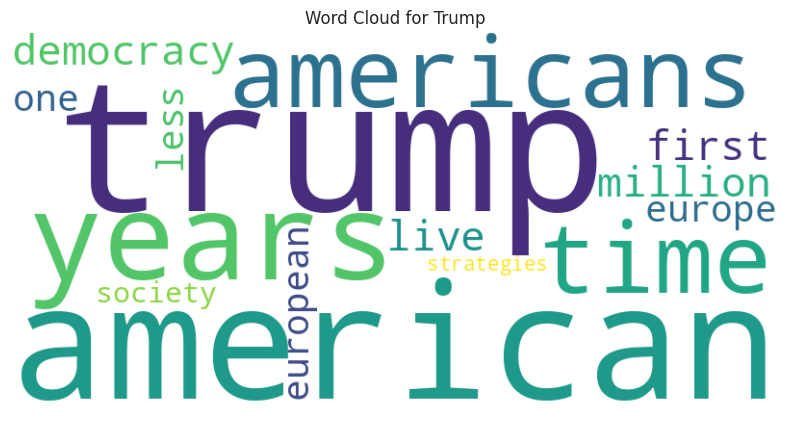

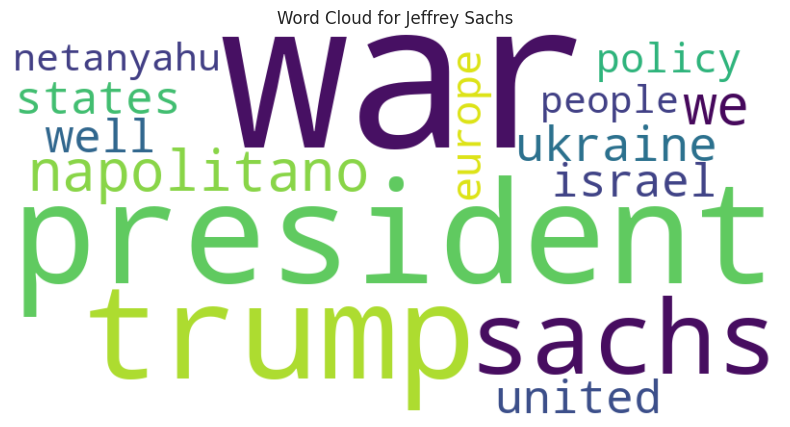

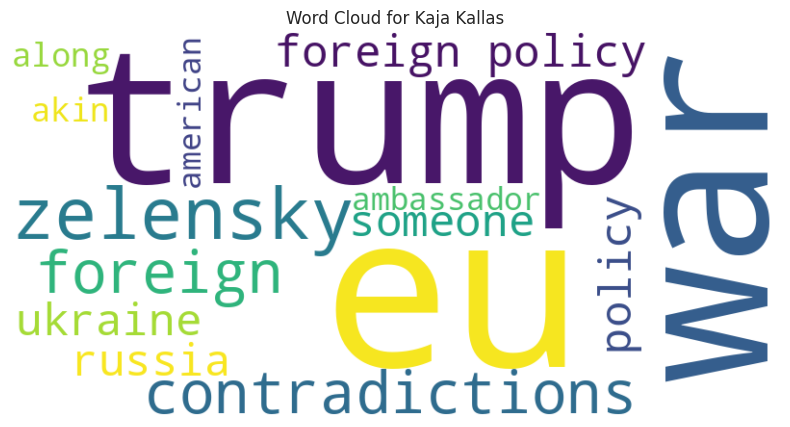

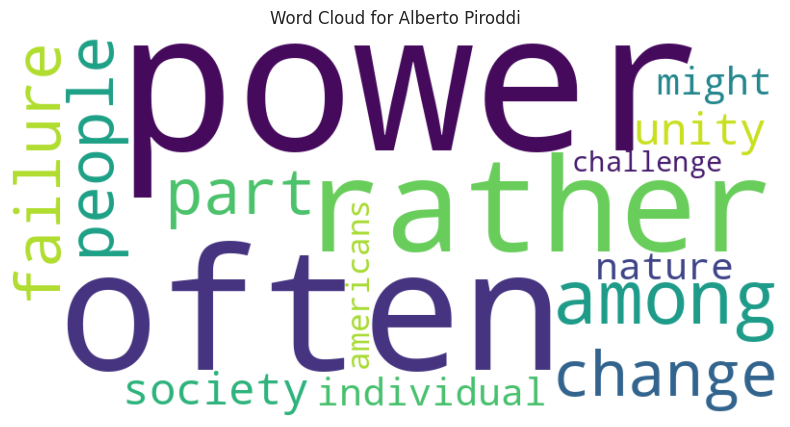

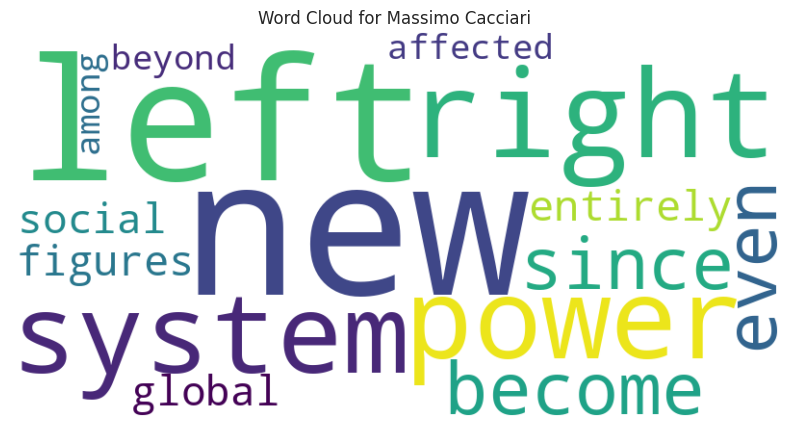

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Generate and display word clouds for each article
for article, words in top_words_per_article.items():
    # Ensure words is a list of tuples before unpacking
    if isinstance(words, list) and all(isinstance(item, tuple) and len(item) == 2 for item in words):
        word_freq = dict(words)  # Convert list of tuples to dictionary

        # Generate word cloud
        wordcloud = WordCloud(width=800, height=400, background_color="white").generate_from_frequencies(word_freq)

        # Plot the word cloud
        plt.figure(figsize=(10, 5))
        plt.imshow(wordcloud, interpolation="bilinear")
        plt.axis("off")  # Hide axes
        plt.title(f"Word Cloud for {article}")
        plt.show()
    else:
        print(f"Skipping {article} due to incorrect data format.")


In [ ]:
from nltk.corpus import stopwords

# Load default stop words
stop_words = set(stopwords.words('english'))

# List of frequent words from your analysis
custom_stop_words = {
    "trump","years","europe","european","americans","american","democracy","live","trump","president","war","sachs",
    "napolitano","zelensky","eu","change","contradiction","power","failure","people","society",
    "new","left","right","entirely"
}

# Update the stop word list
stop_words.update(custom_stop_words)

print("Updated stop words list:", stop_words)


Updated stop words list: {'are', 'y', 'had', "mightn't", 'wouldn', 'ours', 'because', "he'd", 'is', 'having', 'very', "mustn't", 'this', 'why', 'trump', 'do', 'during', 'what', 'before', 'your', 'didn', "hasn't", 'there', "she'll", 'itself', 'own', 'weren', "he's", 'ourselves', "he'll", 'again', 'napolitano', 'yours', "we're", 'an', 't', 'that', "we'll", "should've", 'but', 'by', 'doesn', 'out', "they'll", 'these', 'above', 'been', 'will', 'how', 'you', 'of', 'hers', 'yourselves', 'hadn', 'american', 'failure', 'just', 'd', "isn't", "hadn't", 'to', 'more', 'once', 'ma', 'live', 'other', 'in', 'few', 'won', 'from', 'off', "you're", 'contradiction', 'democracy', 'all', 'be', 'into', 'too', 'whom', 'haven', 'only', 'society', 'right', 'same', 'who', 'shouldn', 'it', 'a', 'does', "it'll", 'isn', 'so', 'themselves', "aren't", 'zelensky', 'any', 'entirely', 'i', 'don', 'here', "they'd", 'power', "i'll", "weren't", 'his', 'then', 'now', 'sachs', "it's", 'no', "we'd", 'them', 'through', 'over'

In [ ]:
from collections import Counter

# Prepare a structure where each article's top words are just strings (no counts)
# If your `top_words_per_article` contains tuples like (word, count), extract only the word
cleaned_top_words = {
    article: [word if isinstance(word, str) else word[0] for word in words]
    for article, words in top_words_per_article.items()
}

# Count how many documents each word appears in
word_in_docs = Counter()
for words in cleaned_top_words.values():
    unique_words = set(words)
    for word in unique_words:
        word_in_docs[word] += 1

# Set threshold: word must appear in at least half the documents
threshold = max(1, int(0.5 * len(cleaned_top_words)))

# Get custom stop words
custom_stop_words = [word for word, count in word_in_docs.items() if count >= threshold]

# Save to file
with open("custom_stop_words.txt", "w", encoding="utf-8") as f:
    for word in custom_stop_words:
        f.write(word + "\n")


In [ ]:
# Count how many articles contain each word
word_occurrences = Counter()

for article in dtm_df.columns:
    word_occurrences[article] = (dtm_df[article] > 0).sum()  # Count occurrences across documents

# Sort words by number of routines they occur in
sorted_word_occurrences = word_occurrences.most_common(15)

# Display results
print("\nMost Common Words Across All Articles (With Routine Count):")
for word, count in sorted_word_occurrences:
    print(f"{word}: {count} articles")



Most Common Words Across All Articles (With Routine Count):
among: 4 articles
even: 4 articles
foreign: 4 articles
global: 4 articles
history: 4 articles
human: 4 articles
least: 4 articles
made: 4 articles
new: 4 articles
power: 4 articles
reality: 4 articles
trump: 4 articles
would: 4 articles
america: 3 articles
american: 3 articles


In [ ]:
from collections import Counter

# Assuming you have a DataFrame named corpus_df with a column 'Text' (the articles)
# And a set named custom_stop_words

# Step 1: Count how many documents each word appears in (filtered to only custom stop words)
word_in_docs = Counter()

for text in corpus_df['Text']:
    words = set(text.lower().split())
    for word in words:
        if word in custom_stop_words:
            word_in_docs[word] += 1

# Step 2: Set threshold for frequency across documents (≥ 50% of documents)
threshold = max(1, int(0.5 * len(corpus_df)))  # 50% of article count

# Step 3: Get final stopwords = words that are custom AND appear in ≥ 50% of documents
high_freq_custom_words = [word for word, count in word_in_docs.items() if count >= threshold]

print("\nCustom stop words appearing in ≥ 50% of articles:")
print(high_freq_custom_words)

# Step 4: Remove those words from each article
def clean_article(text, remove_words):
    return ' '.join([word for word in text.split() if word.lower() not in remove_words])

# Apply to all articles
corpus_df['Cleaned_Text'] = corpus_df['Text'].apply(lambda text: clean_article(text, set(high_freq_custom_words)))

# Preview cleaned output
print("\nSample cleaned article:")
print(corpus_df['Cleaned_Text'].iloc[0])



Custom stop words appearing in ≥ 50% of articles:
['society', 'among', 'power', 'americans', 'trump', 'policy', 'people', 'american', 'europe', 'war', 'ukraine']

Sample cleaned article:
pino arlacchi trump’s inaugural address first executive orders typify debut populist leader promising rescue perceived plight lead toward path rebirth many times seen dismal spectacle mussolini hitler berlusconi today’s xenophobic european leaders countless figures promised national greatness prosperity personal charisma collapse ignominiously—and often tragically—under weight economic crises wars betrayal interests initially supported true came democratic elections however rise reinforces primary argument elective democracy plato first articulate concern addressing athenian agora plagued demagogues serving one percent time plato belonged electoral processes vulnerable irrational forces assume voters possess ability assess candidates platforms—a capacity clearly lacking churchill’s quip underscores po

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

# Load the custom stop words
with open("custom_stop_words.txt", "r", encoding="utf-8") as file:
    custom_stop_words = file.read().splitlines()

# Create the Document-Term Matrix (DTM) with the updated stop words
vectorizer = CountVectorizer(stop_words='english')  # Start with standard stop words
vectorizer.stop_words_ = vectorizer.get_stop_words().union(set(custom_stop_words))  # Add custom stop words

dtm = vectorizer.fit_transform(corpus_df['Text'])  # Recreate the DTM

# Convert DTM into a DataFrame
dtm_df = pd.DataFrame(dtm.toarray(), columns=vectorizer.get_feature_names_out(), index=corpus_df['Article'])

# Save the updated DTM to a CSV file
dtm_df.to_csv("updated_document_term_matrix.csv")

# Print a preview
print("\nUpdated Document-Term Matrix:")
print(dtm_df.head())



Updated Document-Term Matrix:
                  ability  absolutely  abstention  abstract  absurd  accident  \
Article                                                                         
Trump                   1           0           0         0       0         0   
Jeffrey Sachs           0           4           0         0       1         0   
Kaja Kallas             0           0           0         0       0         0   
Alberto Piroddi         1           0           0         1       0         1   
Massimo Cacciari        0           0           2         0       0         0   

                  accountable  achieve  achievements  acknowledge  ...  years  \
Article                                                            ...          
Trump                       0        0             0            0  ...      6   
Jeffrey Sachs               0        1             0            0  ...      5   
Kaja Kallas                 0        0             0            0  ...      0

Generating word cloud for: Trump


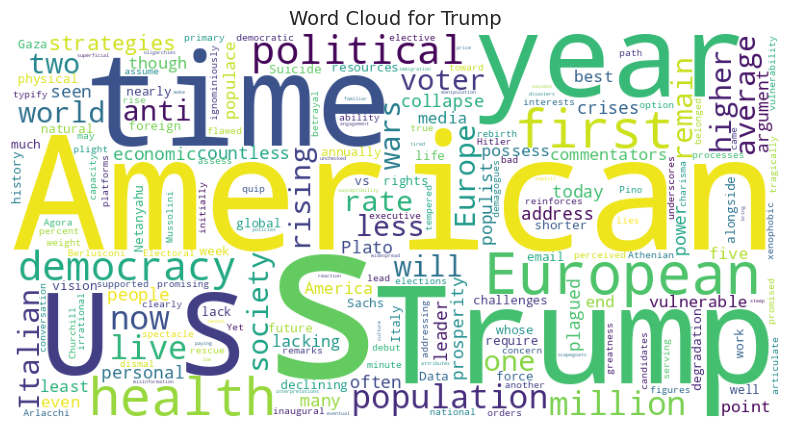

Generating word cloud for: Jeffrey Sachs


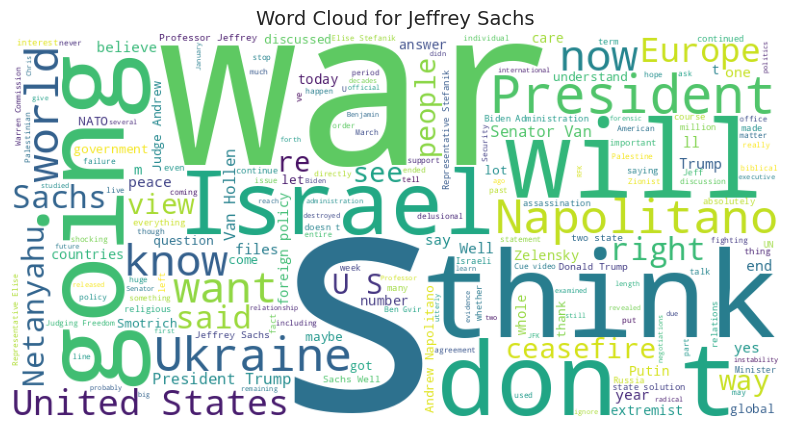

Generating word cloud for: Kaja Kallas


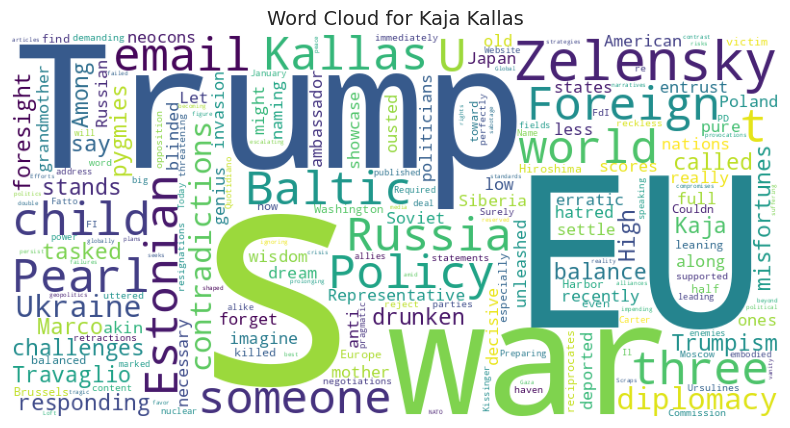

Generating word cloud for: Alberto Piroddi


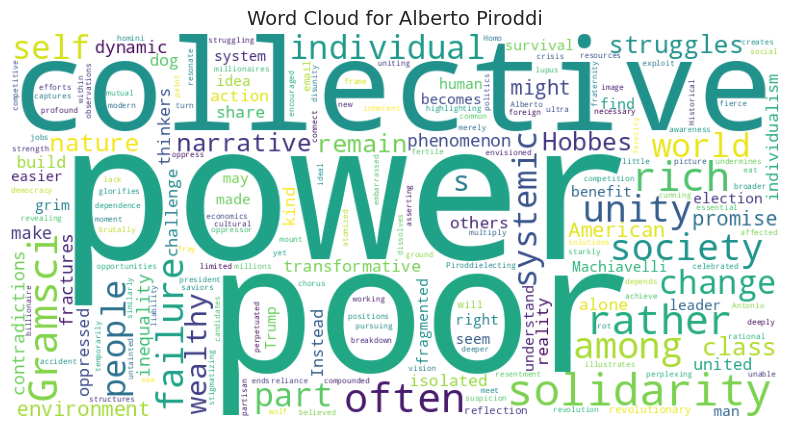

Generating word cloud for: Massimo Cacciari


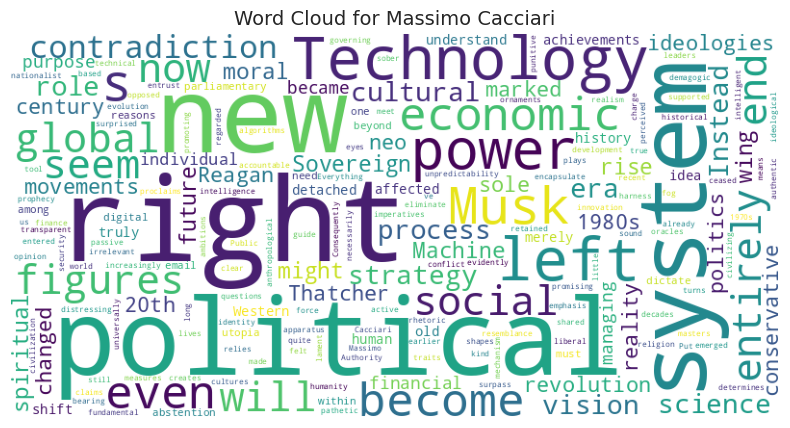

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Function to generate and display word clouds
def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(title, fontsize=14)
    plt.show()

# Generate word clouds for each article
for article, text in extracted_articles.items():
    print(f"Generating word cloud for: {article}")
    generate_word_cloud(text, title=f"Word Cloud for {article}")


In [ ]:
import pandas as pd

# Function to count unique words in each article
def count_unique_words(corpus_df):
    unique_word_counts = {}

    for article, text in corpus_df.items():
        words = text.split()
        unique_words = set(words)  # Get unique words
        unique_word_counts[article] = len(unique_words)
    return unique_word_counts

# Call function to get unique word counts
unique_word_counts = count_unique_words(cleaned_articles)

# Convert to DataFrame for better visualization
unique_words_df = pd.DataFrame(list(unique_word_counts.items()), columns=['Article', 'Unique Word Count'])

# Display results
print(unique_words_df)




            Article  Unique Word Count
0             Trump                539
1     Jeffrey Sachs                900
2       Kaja Kallas                211
3   Alberto Piroddi                400
4  Massimo Cacciari                488


In [ ]:
import pandas as pd

# Define an estimated speaking speed (words per minute)
WORDS_PER_MINUTE = 150  # Average speaking rate

# Function to calculate WPM
def calculate_wpm(corpus_df):
    wpm_dict = {}

    for article, text in corpus_df.items():
        total_words = len(text.split())  # Count total words
        estimated_minutes = total_words / WORDS_PER_MINUTE  # Compute estimated speaking time
        wpm_dict[article] = round(estimated_minutes, 2)  # Round to 2 decimal places

    return wpm_dict

# Call function to get estimated WPM
wpm_results = calculate_wpm(extracted_articles)

# Convert to DataFrame
wpm_df = pd.DataFrame(list(wpm_results.items()), columns=['Article', 'Estimated Speaking Time (minutes)'])

# Display results
print(wpm_df)




            Article  Estimated Speaking Time (minutes)
0             Trump                               7.63
1     Jeffrey Sachs                              21.00
2       Kaja Kallas                               2.45
3   Alberto Piroddi                               6.18
4  Massimo Cacciari                               7.09


<ipython-input-48-a59d7d72f5cc>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=wpm_df["Estimated Speaking Time (minutes)"], y=wpm_df["Article"], palette="viridis")


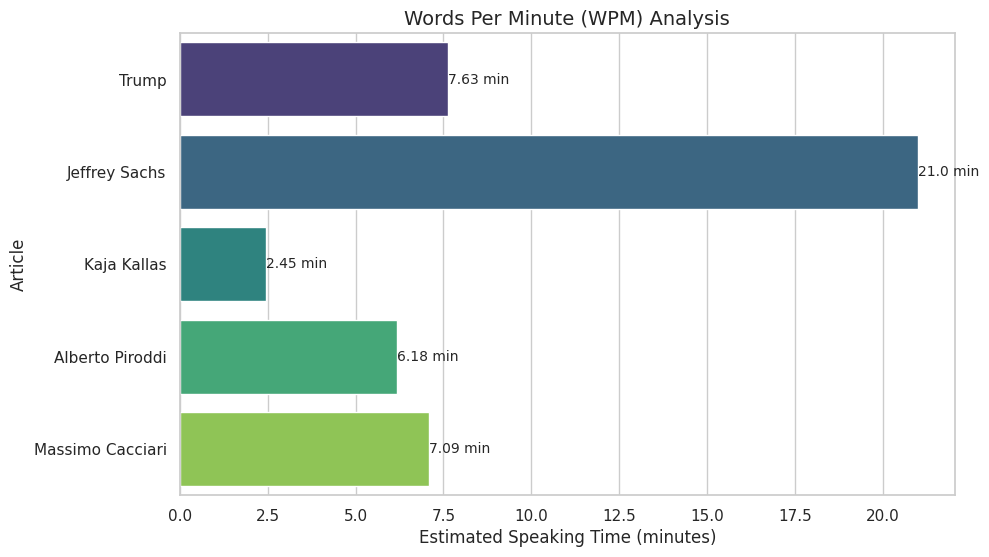

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=wpm_df["Estimated Speaking Time (minutes)"], y=wpm_df["Article"], palette="viridis")

# Labels & Title
plt.xlabel("Estimated Speaking Time (minutes)", fontsize=12)
plt.ylabel("Article", fontsize=12)
plt.title("Words Per Minute (WPM) Analysis", fontsize=14)

# Show values on bars
for index, value in enumerate(wpm_df["Estimated Speaking Time (minutes)"]):
    plt.text(value, index, f"{value} min", va='center', fontsize=10)

# Show the plot

plt.show()


In [ ]:
# Function to calculate vocabulary size and WPM
def calculate_vocab_size(text):
    words = text.split()
    unique_words = set(words)
    return len(words), len(unique_words)

# Store results in a DataFrame
vocab_data = []
for name, text in cleaned_articles.items():
    total_words, unique_words = calculate_vocab_size(text)
    vocab_data.append([name, total_words, unique_words])

vocab_df = pd.DataFrame(vocab_data, columns=['Article', 'Total Words', 'Unique Words'])

# Save vocabulary statistics to a CSV
vocab_df.to_csv("vocabulary_stats.csv", index=False)

# Print the vocabulary statistics
print("\nVocabulary Statistics:")
print(vocab_df)



Vocabulary Statistics:
            Article  Total Words  Unique Words
0             Trump          680           539
1     Jeffrey Sachs         1725           900
2       Kaja Kallas          231           211
3   Alberto Piroddi          516           400
4  Massimo Cacciari          601           488


In [ ]:
# Define a list of profanity words
profanity_list = {"damn", "hell", "shit", "fuck", "bitch", "bastard", "asshole", "crap"}

# Function to count profanity
def count_profanity(text):
    words = text.split()
    profanity_count = sum(1 for word in words if word in profanity_list)
    return profanity_count

# Store profanity statistics in a DataFrame
profanity_data = []
for name, text in cleaned_articles.items():
    profanity_count = count_profanity(text)
    profanity_data.append([name, profanity_count])

profanity_df = pd.DataFrame(profanity_data, columns=['Article', 'Profanity Count'])

# Save profanity statistics to a CSV
profanity_df.to_csv("profanity_stats.csv", index=False)

# Print profanity statistics
print("\nProfanity Statistics:")
print(profanity_df)



Profanity Statistics:
            Article  Profanity Count
0             Trump                1
1     Jeffrey Sachs                0
2       Kaja Kallas                0
3   Alberto Piroddi                0
4  Massimo Cacciari                0


# additional

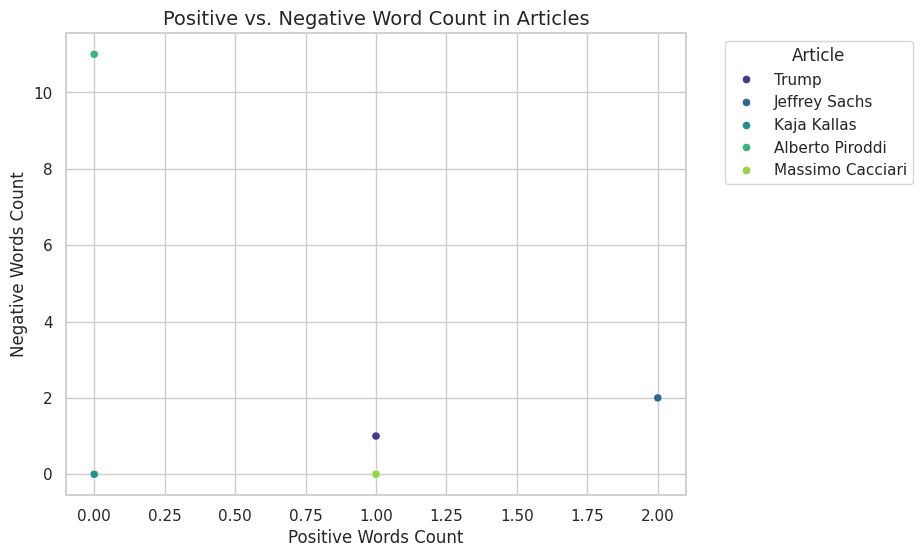

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

# Define positive and negative words
positive_words = {"good", "happy", "excellent", "love", "joy", "success"}
negative_words = {"bad", "sad", "hate", "failure", "terrible", "poor"}

# Function to count word categories
def count_words(text, word_list):
    words = text.lower().split()
    return sum(1 for word in words if word in word_list)

# Store counts in a list
comparison_data = []

for name, text in cleaned_articles.items():
    positive_count = count_words(text, positive_words)
    negative_count = count_words(text, negative_words)
    comparison_data.append([name, positive_count, negative_count])

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_data, columns=['Article', 'Positive Count', 'Negative Count'])

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=comparison_df["Positive Count"], y=comparison_df["Negative Count"], hue=comparison_df["Article"], palette="viridis")

# Labels and Title
plt.xlabel("Positive Words Count", fontsize=12)
plt.ylabel("Negative Words Count", fontsize=12)
plt.title("Positive vs. Negative Word Count in Articles", fontsize=14)
plt.legend(title="Article", bbox_to_anchor=(1.05, 1), loc='upper left')

# Show plot
plt.show()


alberto piroddi speaks negative words more.
jeffery sachs speaks positive more.
kaja kallas neither speaks positive nor neative.
trump and masimo cacciri speaks more positive but masimo didnt use any negative word.








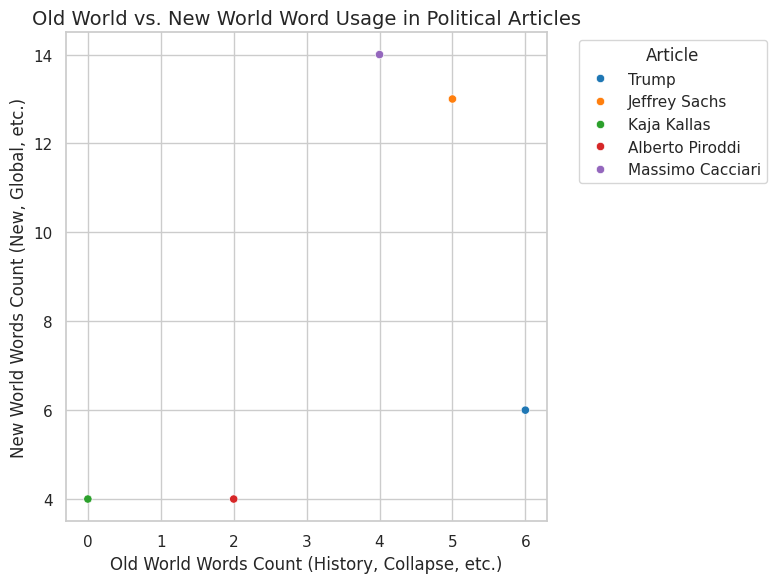

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define Old World (past-focused) and New World (future-focused) terms
old_world_words = {"history", "collapse", "decades", "deep"}
new_world_words = {"new", "reality", "global", "foreign"}

# Function to count words from a specific list
def count_theme_words(text, word_set):
    words = text.lower().split()
    return sum(1 for word in words if word in word_set)

# Example: cleaned_articles is a dictionary of article_name: article_text
# Make sure cleaned_articles is defined before running this
comparison_data = []

for name, text in cleaned_articles.items():
    old_count = count_theme_words(text, old_world_words)
    new_count = count_theme_words(text, new_world_words)
    comparison_data.append([name, old_count, new_count])

# Convert to DataFrame
comparison_df = pd.DataFrame(comparison_data, columns=["Article", "Old World Count", "New World Count"])

# Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=comparison_df,
    x="Old World Count",
    y="New World Count",
    hue="Article",
    palette="tab10"
)

# Labels and Title
plt.xlabel("Old World Words Count (History, Collapse, etc.)", fontsize=12)
plt.ylabel("New World Words Count (New, Global, etc.)", fontsize=12)
plt.title("Old World vs. New World Word Usage in Political Articles", fontsize=14)
plt.legend(title="Article", bbox_to_anchor=(1.05, 1), loc="upper left")

# Show plot
plt.tight_layout()
plt.show()


1. Massimo Cacciari & Jeffrey Sachs lean heavily New World.
2. Trump leans Old World.
3. Kaja Kallas & Alberto Piroddi are minimally engaged with either theme.



# **4th assignment**

In [ ]:
import pandas as pd
from textblob import TextBlob

# Load the corpus
corpus_df = pd.read_csv("corpus.csv")

# Apply TextBlob's sentiment analysis
# polarity tells if speaker is positive or negative
corpus_df["Polarity"] = corpus_df["Text"].apply(lambda x: TextBlob(x).sentiment.polarity)
# subjectivity tells if speaker is factual or opinionated
corpus_df["Subjectivity"] = corpus_df["Text"].apply(lambda x: TextBlob(x).sentiment.subjectivity)

# Preview results
print(corpus_df[["Article", "Polarity", "Subjectivity"]])


            Article  Polarity  Subjectivity
0             Trump  0.043222      0.313546
1     Jeffrey Sachs  0.050589      0.427063
2       Kaja Kallas  0.066641      0.362937
3   Alberto Piroddi -0.011299      0.537485
4  Massimo Cacciari  0.077548      0.347857


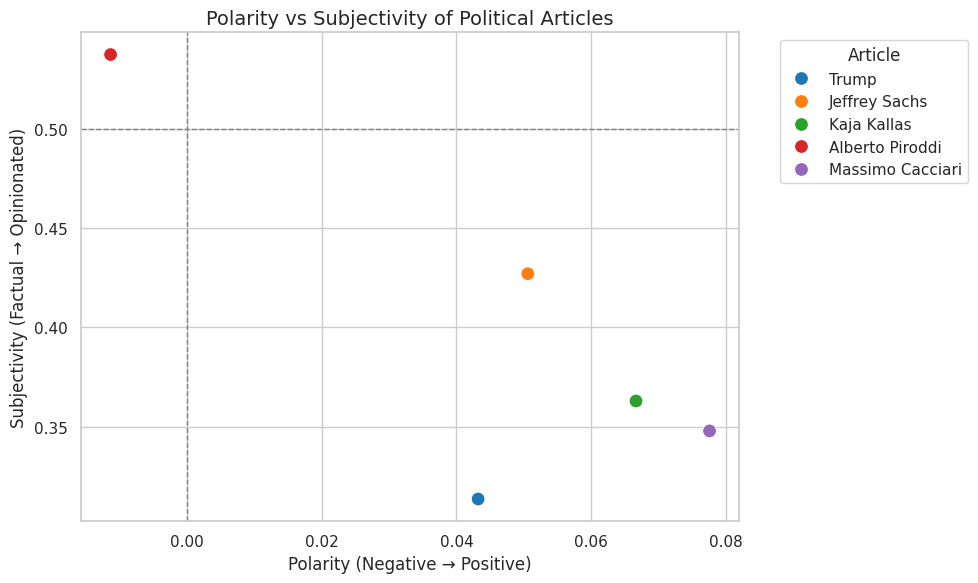

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set(style="whitegrid")

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=corpus_df, x='Polarity', y='Subjectivity', hue='Article', palette='tab10', s=100)

# Add labels and title
plt.title("Polarity vs Subjectivity of Political Articles", fontsize=14)
plt.xlabel("Polarity (Negative → Positive)", fontsize=12)
plt.ylabel("Subjectivity (Factual → Opinionated)", fontsize=12)

# Customize plot appearance
plt.axvline(0, color='gray', linestyle='--', linewidth=1)  # Neutral polarity line
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)  # Mid subjectivity line
plt.legend(title='Article', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# Show the plot
plt.show()


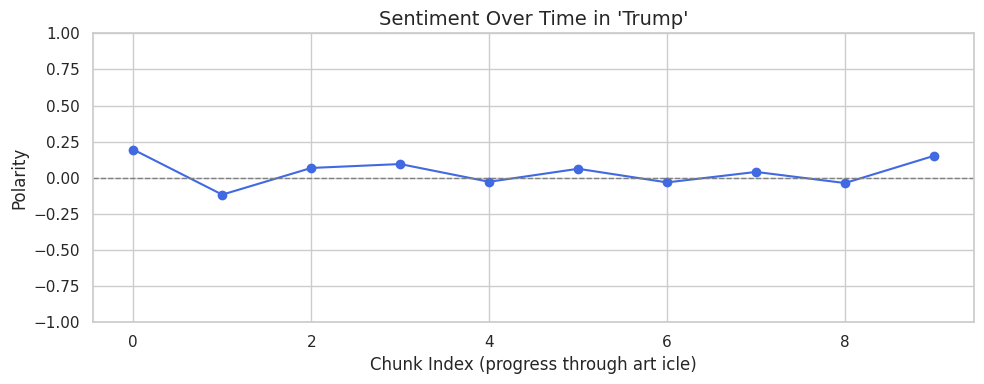

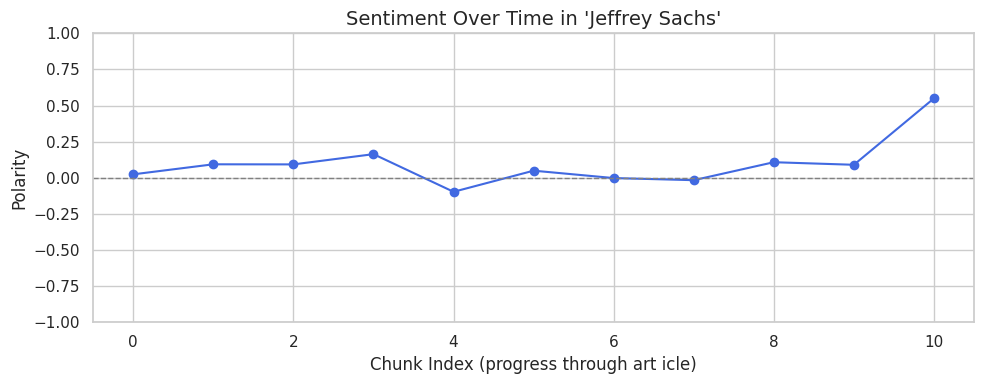

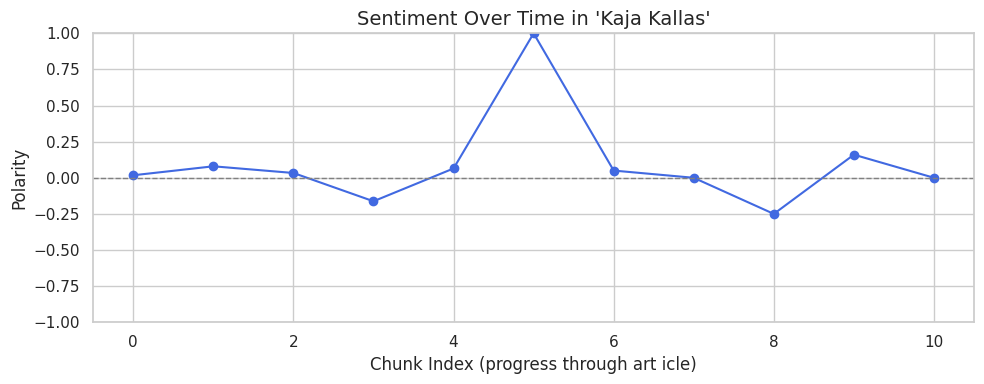

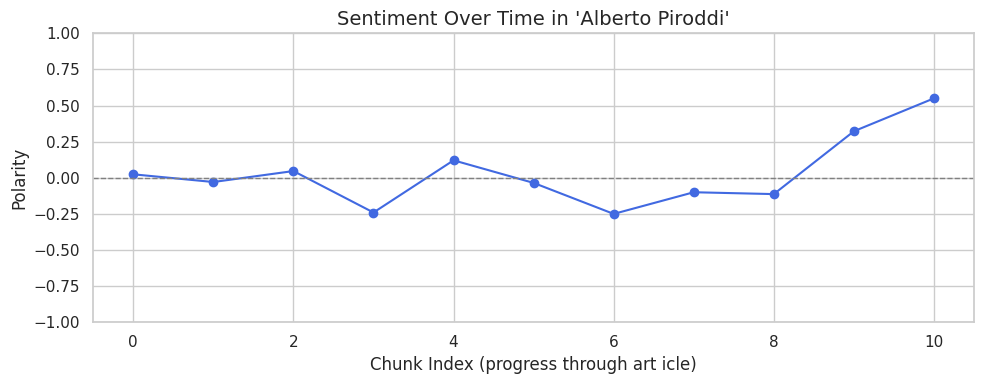

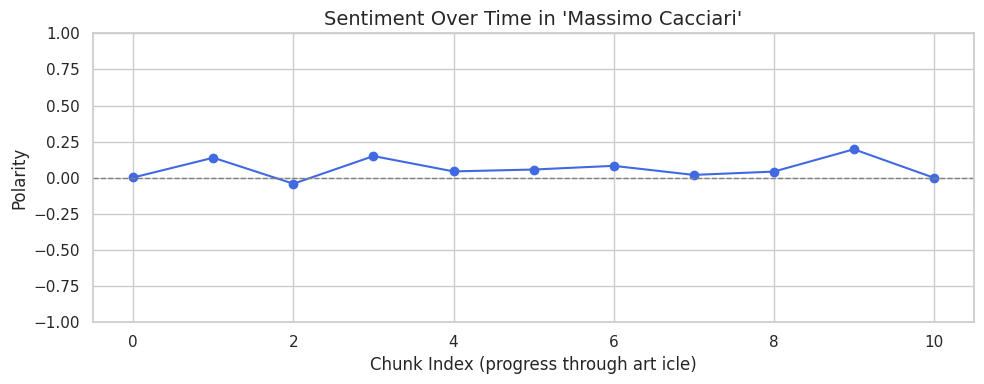

In [ ]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import numpy as np

# Function to split text into dynamic chunks based on article length
def get_sentiment_over_time(text, num_chunks=10):
    words = text.split()
    chunk_size = max(1, len(words) // num_chunks)  # At least 1 word per chunk
    chunks = [' '.join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]
    polarity_scores = [TextBlob(chunk).sentiment.polarity for chunk in chunks]
    return polarity_scores

# Plot sentiment over time for each article
for article, text in cleaned_articles.items():
    sentiment_scores = get_sentiment_over_time(text, num_chunks=10)

    plt.figure(figsize=(10, 4))
    plt.plot(sentiment_scores, marker='o', linestyle='-', color='royalblue')
    plt.title(f"Sentiment Over Time in '{article}'", fontsize=14)
    plt.xlabel("Chunk Index (progress through art icle)")
    plt.ylabel("Polarity")
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Neutral line
    plt.ylim(-1, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


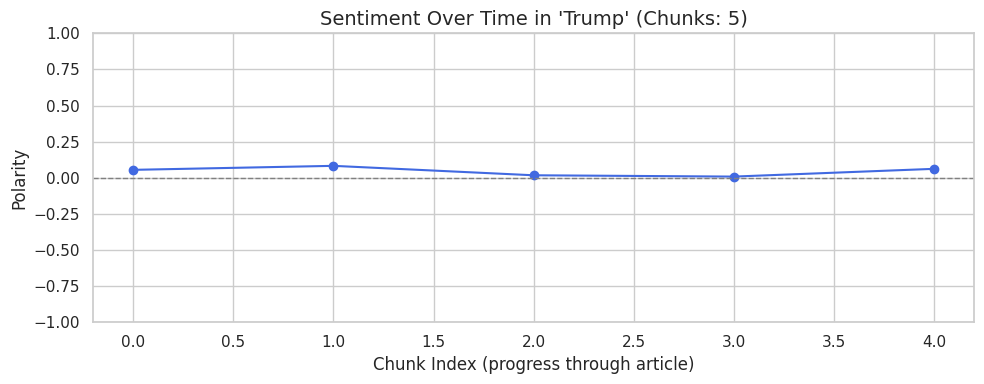

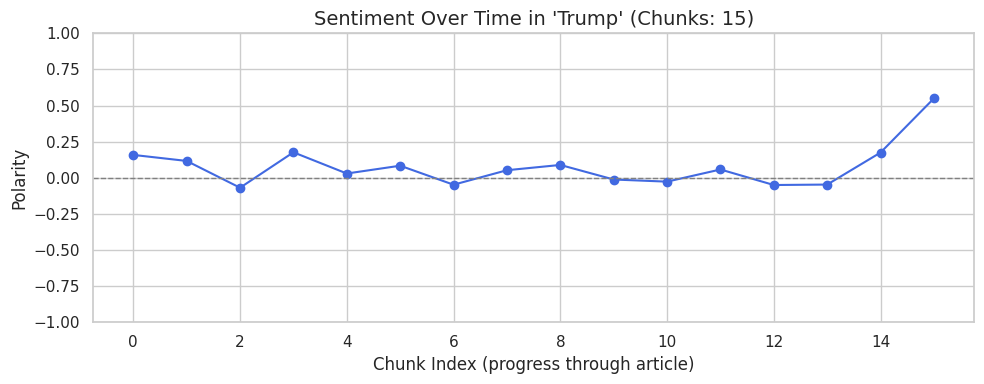

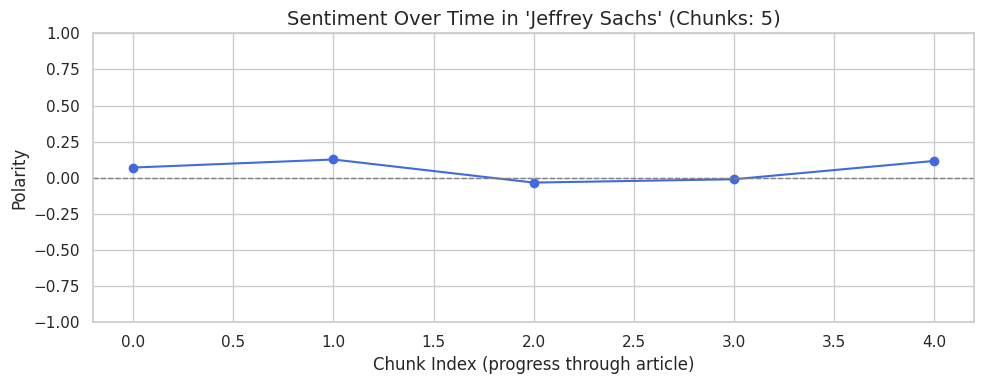

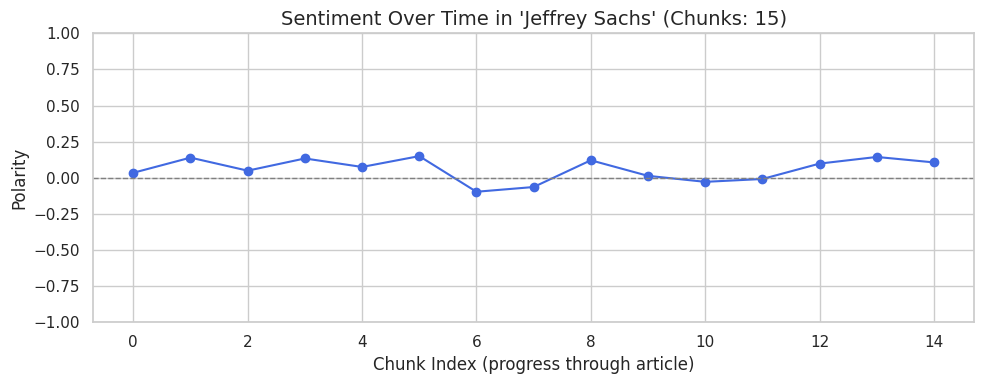

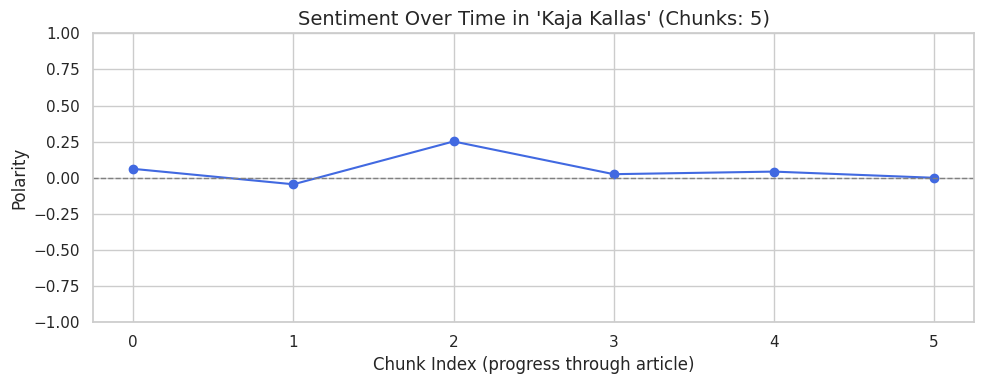

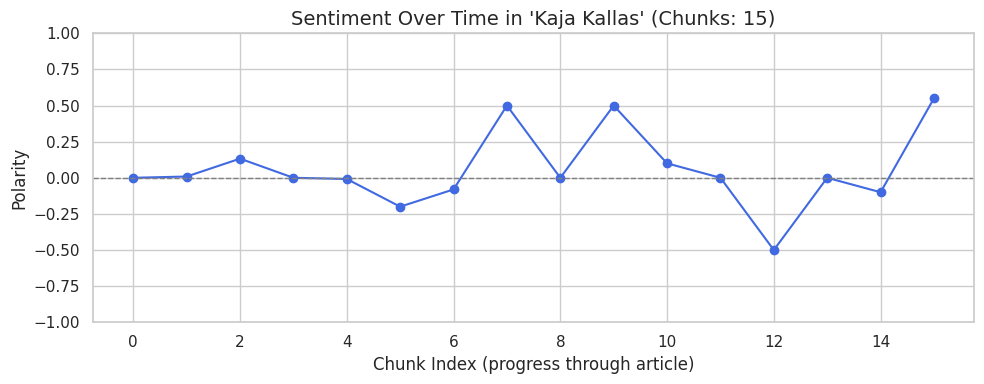

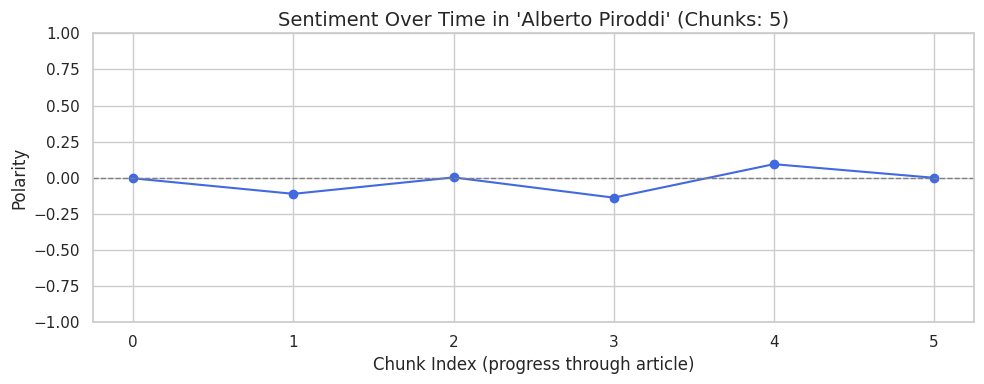

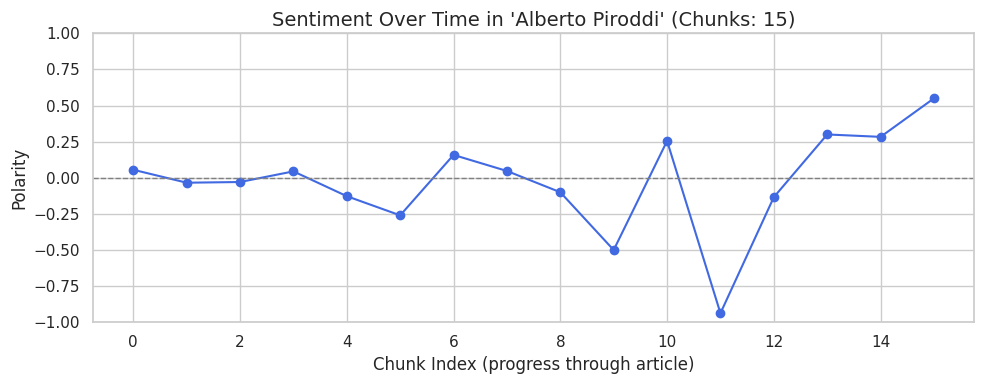

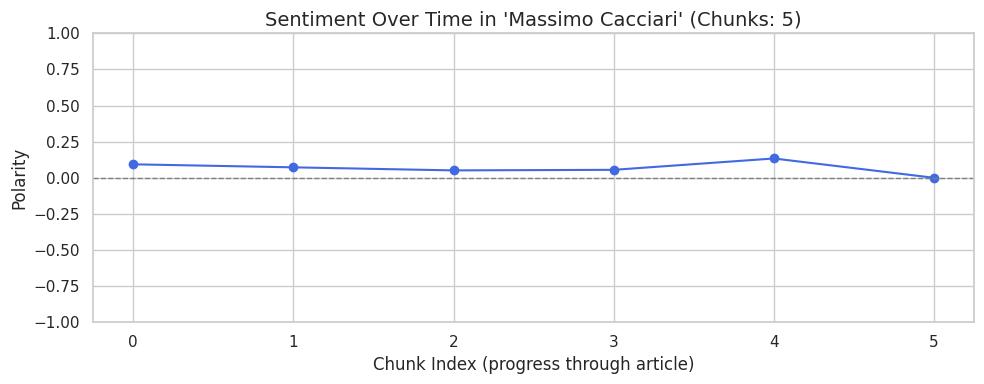

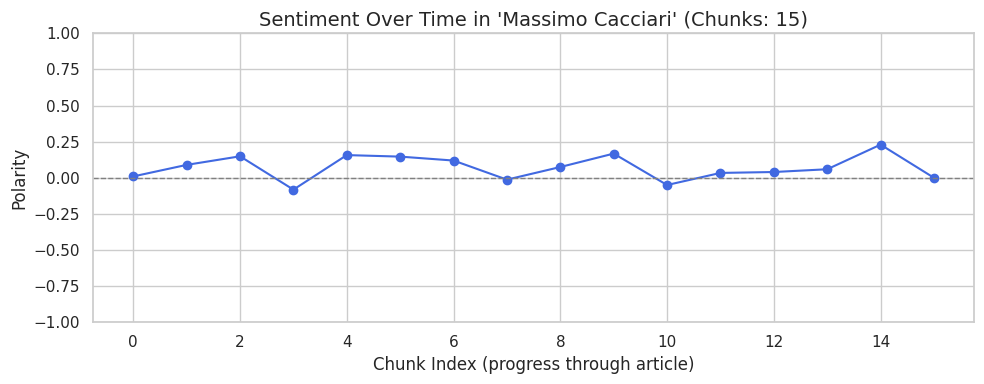

In [ ]:
from textblob import TextBlob
import matplotlib.pyplot as plt
import numpy as np

# Function to split article text into chunks and get polarity for each chunk
def get_sentiment_over_time(text, num_chunks):
    words = text.split()
    chunk_size = max(1, len(words) // num_chunks)
    chunks = [' '.join(words[i:i+chunk_size]) for i in range(0, len(words), chunk_size)]
    polarity_scores = [TextBlob(chunk).sentiment.polarity for chunk in chunks]
    return polarity_scores

# Try different numbers of chunks
chunk_options = [5,15]

for article, text in cleaned_articles.items():
    for num_chunks in chunk_options:
        sentiment_scores = get_sentiment_over_time(text, num_chunks)

        plt.figure(figsize=(10, 4))
        plt.plot(sentiment_scores, marker='o', linestyle='-', color='royalblue')
        plt.title(f"Sentiment Over Time in '{article}' (Chunks: {num_chunks})", fontsize=14)
        plt.xlabel("Chunk Index (progress through article)")
        plt.ylabel("Polarity")
        plt.axhline(0, color='gray', linestyle='--', linewidth=1)  # Neutral line
        plt.ylim(-1, 1)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
